# RiNALMo MMD calibration: what do the numbers mean?

Build a "ruler" for RiNALMo MMD distances:
- 0.0 = identical sequences
- ??? = 1 mutation
- ??? = biologically similar (same family)
- ??? = "looks like RNA but different"
- ??? = random genomic noise

Experiments: point mutations, indels, shifts, shuffles, random, real RNA vs noise.

In [1]:
import sys, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "modules" / "RiNALMo"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "RNA-FM"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "pipeline"))

import short_ncrna as sn
from pyrion import TwoBitAccessor
from pyrion.io.bed import read_bed12_file

SEED = 42
random.seed(SEED); np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

from rinalmo.pretrained import get_pretrained_model
rin_model, rin_alpha = get_pretrained_model(model_name="giga-v1")
rin_model = rin_model.to(device).eval()

def emb(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    tokens = torch.tensor(
        rin_alpha.batch_tokenize([rna]), dtype=torch.int64, device=device
    )
    with torch.no_grad():
        out = rin_model(tokens)
    return out["representation"][0, 1:1 + len(rna), :].cpu().float().numpy()

def mmd(a, b):
    return sn._compute_mmd(emb(a), emb(b))

print(f"RiNALMo on {device}")

RiNALMo on mps


## Reference sequences

Use real ncRNAs of different lengths + types as test cases.

In [2]:
BED_PATH = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.input.w.tRNA.bed"
TWOBIT_PATH = REPO_ROOT / "input_data" / "2bit" / "hg38.2bit"
META_PATH = REPO_ROOT / "input_data" / "reference_annotation" / "test_sample.metadata.tsv"

accessor = TwoBitAccessor(str(TWOBIT_PATH))
bed_data = read_bed12_file(str(BED_PATH))
meta_df = pd.read_csv(META_PATH, sep="\t")
biotype_map = dict(zip(meta_df["transcript_id"], meta_df["transcript_biotype"]))

# Pick a few real sequences of different types and lengths
TARGETS = {
    "tRNA-Asn-GTT-chr1-140": "tRNA (74 nt)",
    "ENST00000362168.1": "miRNA (110 nt)",
    "ENST00000383885.1": "snoRNA (135 nt)",
}

ref_seqs = {}
for tid, label in TARGETS.items():
    for t in bed_data:
        if t.id == tid:
            seq = sn._get_spliced_sequence(t, accessor).upper().replace("T", "U")
            ref_seqs[label] = seq
            print(f"  {label}: {len(seq)} nt")
            break

# Also get some random genomic noise windows
rng = random.Random(SEED)
noise_seqs = []
chrom_sizes = {"chr1": 248956422, "chr2": 242193529, "chr3": 198295559,
               "chr5": 181538259, "chr7": 159345973, "chr11": 135086622}
for _ in range(30):
    chrom = rng.choice(list(chrom_sizes.keys()))
    start = rng.randint(0, chrom_sizes[chrom] - 100)
    seq = str(accessor.fetch(chrom, start, start + 74)).upper().replace("T", "U")
    if "N" not in seq:
        noise_seqs.append(seq)

print(f"\nNoise windows: {len(noise_seqs)}")

  tRNA (74 nt): 74 nt
  miRNA (110 nt): 110 nt
  snoRNA (135 nt): 135 nt

Noise windows: 30


## Calibration experiments

For each reference sequence, measure MMD under controlled perturbations.

In [3]:
BASES = "AUGC"

def point_mutate(seq, frac, rng):
    s = list(seq)
    n = max(1, int(round(frac * len(s))))
    for i in rng.sample(range(len(s)), n):
        s[i] = rng.choice([b for b in BASES if b != s[i]])
    return "".join(s)

def insert_at(seq, pos, n, rng):
    ins = "".join(rng.choices(BASES, k=n))
    return seq[:pos] + ins + seq[pos:]

def delete_at(seq, pos, n):
    return seq[:pos] + seq[pos+n:]

def shift_seq(seq, n):
    """Shift sequence: drop n from start, add n random to end."""
    rng_s = random.Random(42)
    tail = "".join(rng_s.choices(BASES, k=abs(n)))
    if n > 0:
        return seq[n:] + tail
    else:
        return tail + seq[:n]

def shuffled(seq, rng):
    s = list(seq); rng.shuffle(s); return "".join(s)

def random_seq(length, rng):
    return "".join(rng.choices(BASES, k=length))

N_REP = 10  # repeats per condition
rng = random.Random(SEED)

all_rows = []
for label, seq in ref_seqs.items():
    L = len(seq)
    ref_e = emb(seq)
    print(f"\n=== {label} ({L} nt) ===")

    # Identical
    all_rows.append({"ref": label, "condition": "identical", "mmd": 0.0})

    # Point mutations
    for frac in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
        n_mut = max(1, int(round(frac * L)))
        for _ in range(N_REP):
            mut = point_mutate(seq, frac, rng)
            all_rows.append({"ref": label, "condition": f"mut_{int(frac*100)}%",
                             "detail": f"{n_mut} changes", "mmd": sn._compute_mmd(ref_e, emb(mut))})
        print(f"  mut {int(frac*100)}% ({n_mut} nt): done")

    # Insertions
    for ins_len in [1, 2, 5, 10, 20]:
        for _ in range(N_REP):
            pos = rng.randint(0, L)
            modified = insert_at(seq, pos, ins_len, rng)
            all_rows.append({"ref": label, "condition": f"ins_{ins_len}",
                             "mmd": sn._compute_mmd(ref_e, emb(modified))})
        print(f"  ins +{ins_len} nt: done")

    # Deletions
    for del_len in [1, 2, 5, 10, 20]:
        if del_len >= L:
            continue
        for _ in range(N_REP):
            pos = rng.randint(0, L - del_len)
            modified = delete_at(seq, pos, del_len)
            all_rows.append({"ref": label, "condition": f"del_{del_len}",
                             "mmd": sn._compute_mmd(ref_e, emb(modified))})
        print(f"  del -{del_len} nt: done")

    # Shifts (slide sequence window)
    for shift in [1, 2, 5, 10, 20]:
        for _ in range(N_REP):
            shifted = shift_seq(seq, shift)
            all_rows.append({"ref": label, "condition": f"shift_{shift}",
                             "mmd": sn._compute_mmd(ref_e, emb(shifted))})
        print(f"  shift +{shift} nt: done")

    # Shuffled (same composition)
    for _ in range(N_REP):
        all_rows.append({"ref": label, "condition": "shuffled",
                         "mmd": sn._compute_mmd(ref_e, emb(shuffled(seq, rng)))})
    print(f"  shuffled: done")

    # Random AUGC
    for _ in range(N_REP):
        all_rows.append({"ref": label, "condition": "random",
                         "mmd": sn._compute_mmd(ref_e, emb(random_seq(L, rng)))})
    print(f"  random: done")

    # Genomic noise (real intergenic)
    for ns in noise_seqs[:N_REP]:
        # Trim/pad noise to same length as ref
        ns_adj = ns[:L] if len(ns) >= L else ns + random_seq(L - len(ns), rng)
        all_rows.append({"ref": label, "condition": "genomic_noise",
                         "mmd": sn._compute_mmd(ref_e, emb(ns_adj))})
    print(f"  genomic noise: done")

cal_df = pd.DataFrame(all_rows)
print(f"\nTotal measurements: {len(cal_df)}")


=== tRNA (74 nt) (74 nt) ===
  mut 1% (1 nt): done
  mut 2% (1 nt): done
  mut 5% (4 nt): done
  mut 10% (7 nt): done
  mut 15% (11 nt): done
  mut 20% (15 nt): done
  mut 30% (22 nt): done
  mut 50% (37 nt): done
  ins +1 nt: done
  ins +2 nt: done
  ins +5 nt: done
  ins +10 nt: done
  ins +20 nt: done
  del -1 nt: done
  del -2 nt: done
  del -5 nt: done
  del -10 nt: done
  del -20 nt: done
  shift +1 nt: done
  shift +2 nt: done
  shift +5 nt: done
  shift +10 nt: done
  shift +20 nt: done
  shuffled: done
  random: done
  genomic noise: done

=== miRNA (110 nt) (110 nt) ===
  mut 1% (1 nt): done
  mut 2% (2 nt): done
  mut 5% (6 nt): done
  mut 10% (11 nt): done
  mut 15% (16 nt): done
  mut 20% (22 nt): done
  mut 30% (33 nt): done
  mut 50% (55 nt): done
  ins +1 nt: done
  ins +2 nt: done
  ins +5 nt: done
  ins +10 nt: done
  ins +20 nt: done
  del -1 nt: done
  del -2 nt: done
  del -5 nt: done
  del -10 nt: done
  del -20 nt: done
  shift +1 nt: done
  shift +2 nt: done
  

## Results

In [4]:
# Summary table: mean MMD per condition, averaged across all reference sequences
summary = cal_df.groupby("condition")["mmd"].agg(["mean", "std", "min", "max", "count"]).reset_index()

# Order conditions logically
cond_order = (["identical"]
    + [f"mut_{p}%" for p in [1, 2, 5, 10, 15, 20, 30, 50]]
    + [f"ins_{n}" for n in [1, 2, 5, 10, 20]]
    + [f"del_{n}" for n in [1, 2, 5, 10, 20]]
    + [f"shift_{n}" for n in [1, 2, 5, 10, 20]]
    + ["shuffled", "random", "genomic_noise"])
cond_order = [c for c in cond_order if c in summary["condition"].values]
summary = summary.set_index("condition").loc[cond_order].reset_index()

print(summary.to_string(index=False, float_format="{:.4f}".format))

    condition   mean    std    min    max  count
    identical 0.0000 0.0000 0.0000 0.0000      3
       mut_1% 0.0000 0.0000 0.0000 0.0000     30
       mut_2% 0.0000 0.0000 0.0000 0.0000     30
       mut_5% 0.0022 0.0120 0.0000 0.0658     30
      mut_10% 0.0136 0.0196 0.0000 0.0775     30
      mut_15% 0.0515 0.0343 0.0000 0.1041     30
      mut_20% 0.0851 0.0329 0.0000 0.1352     30
      mut_30% 0.1288 0.0400 0.0791 0.2377     30
      mut_50% 0.1657 0.0525 0.0889 0.2514     30
        ins_1 0.0000 0.0000 0.0000 0.0000     30
        ins_2 0.0000 0.0000 0.0000 0.0000     30
        ins_5 0.0008 0.0046 0.0000 0.0250     30
       ins_10 0.0166 0.0286 0.0000 0.0889     30
       ins_20 0.0305 0.0453 0.0000 0.1201     30
        del_1 0.0000 0.0000 0.0000 0.0000     30
        del_2 0.0000 0.0000 0.0000 0.0000     30
        del_5 0.0086 0.0196 0.0000 0.0799     30
       del_10 0.0186 0.0307 0.0000 0.0869     30
       del_20 0.0475 0.0410 0.0000 0.1351     30
      shift_1 0.0000

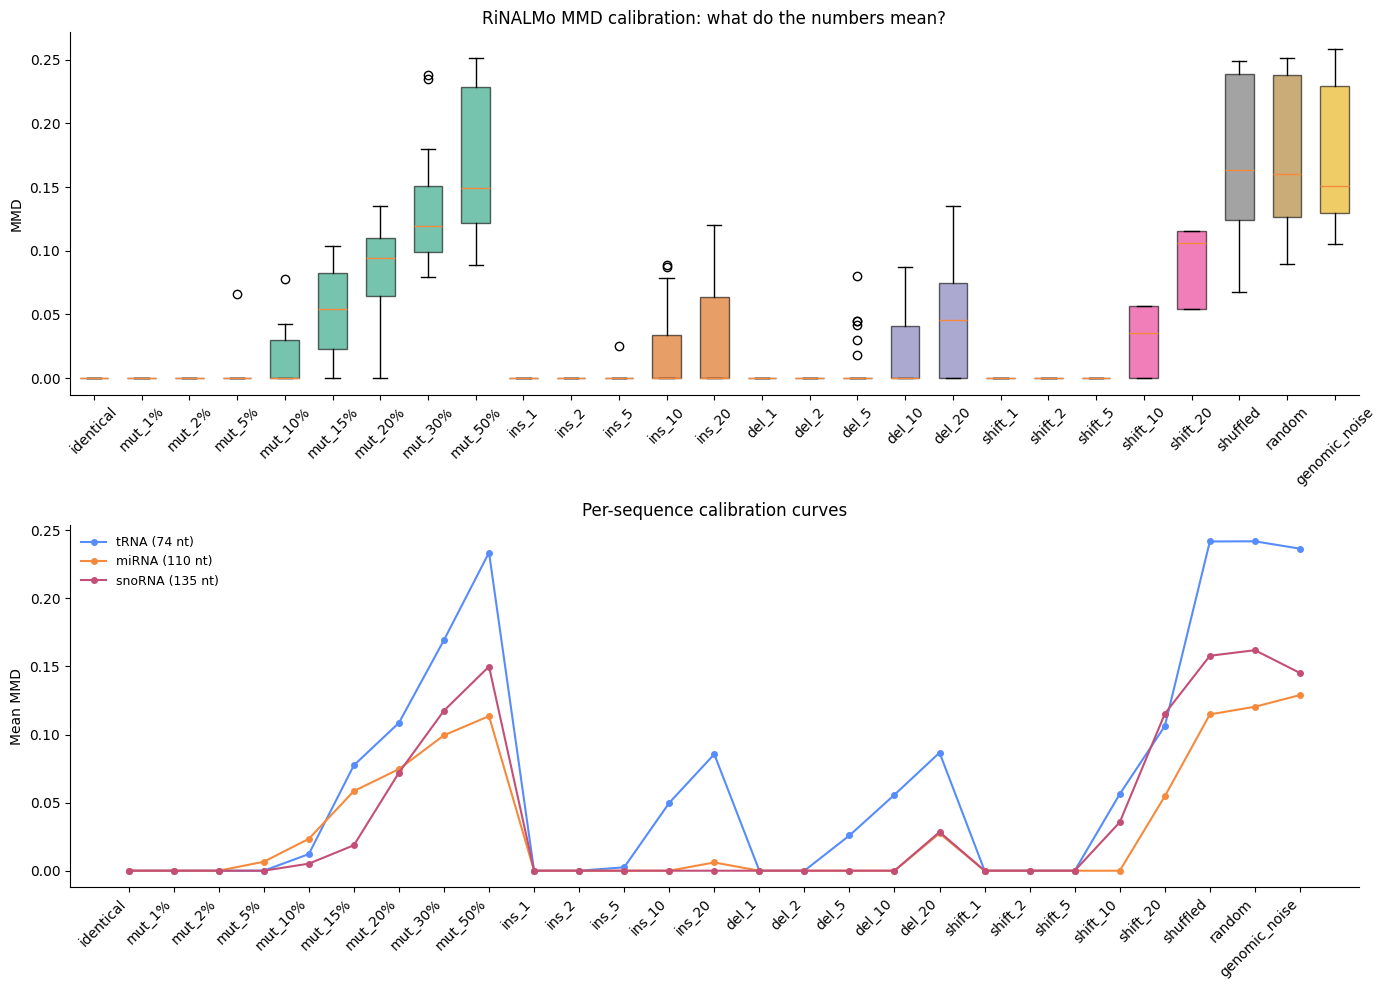

In [5]:
# Visualization: MMD ruler
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: Boxplot of all conditions (averaged across ref sequences)
ax = axes[0]
conditions = cond_order
data = [cal_df[cal_df.condition == c]["mmd"].values for c in conditions]
bp = ax.boxplot(data, tick_labels=conditions, showfliers=True, patch_artist=True, widths=0.6)

# Color by category
cat_colors = {"identical": "#ffffff",
              "mut": "#1b9e77", "ins": "#d95f02", "del": "#7570b3",
              "shift": "#e7298a", "shuffled": "#666666", "random": "#a6761d",
              "genomic": "#e6ab02"}
for i, (patch, cond) in enumerate(zip(bp["boxes"], conditions)):
    cat = cond.split("_")[0] if "_" in cond else cond
    patch.set_facecolor(cat_colors.get(cat, "#cccccc"))
    patch.set_alpha(0.6)

ax.set_ylabel("MMD")
ax.set_title("RiNALMo MMD calibration: what do the numbers mean?")
ax.tick_params(axis="x", rotation=45)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel 2: Per-reference overlay (to see if calibration is sequence-dependent)
ax = axes[1]
for label in ref_seqs:
    sub = cal_df[cal_df.ref == label]
    means = [sub[sub.condition == c]["mmd"].mean() for c in conditions]
    ax.plot(range(len(conditions)), means, marker="o", ms=4, label=label, lw=1.5)

ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, rotation=45, ha="right")
ax.set_ylabel("Mean MMD")
ax.set_title("Per-sequence calibration curves")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Structural preservation test: artificial hairpins

Design hairpins with known secondary structure, then test:
1. **Compensatory mutations** in stems (different sequence, same fold) → low MMD?
2. **Disruptive mutations** in stems (break base-pairing) → high MMD?
3. **Loop mutations** (change loop, keep stem) → lower MMD than stem disruption?

Caveat: we can't be sure RiNALMo captures folding vs just sequence patterns,
but this at least tests whether it's sensitive to structural disruption.

In [7]:
# Design artificial hairpins
# Hairpin structure: 5'--STEM--LOOP--STEM'(revcomp)--3' with flanking single-stranded

# Watson-Crick complements in RNA
wc = {"A": "U", "U": "A", "G": "C", "C": "G"}

def make_hairpin(flank5, stem, loop, flank3):
    """Build a hairpin: flank5 + stem + loop + revcomp(stem) + flank3."""
    stem_rc = "".join(wc[b] for b in reversed(stem))
    return flank5 + stem + loop + stem_rc + flank3

def compensatory_mutate_stem(stem, n_pairs, rng):
    """Mutate n base pairs in stem with compensatory changes (preserve pairing)."""
    s = list(stem)
    positions = rng.sample(range(len(s)), min(n_pairs, len(s)))
    for p in positions:
        new_base = rng.choice([b for b in "AUGC" if b != s[p]])
        s[p] = new_base
    new_stem = "".join(s)
    return new_stem  # the revcomp will be recomputed in make_hairpin

def disrupt_stem(stem, n_mismatches, rng):
    """Introduce mismatches in stem (change one side only, breaking pairing)."""
    s = list(stem)
    positions = rng.sample(range(len(s)), min(n_mismatches, len(s)))
    for p in positions:
        s[p] = rng.choice([b for b in "AUGC" if b != s[p] and b != wc[s[p]]])
    return "".join(s)

# Define 3 hairpins of different sizes
hairpins = {
    "small (50nt)": {
        "flank5": "AUGGCUAACG",  # 10 nt
        "stem":   "GCUAGCUAGCUAGC",  # 14 nt stem (14 bp)
        "loop":   "UUCG",  # 4 nt tetraloop
        "flank3": "CGAUUCCGA",  # ~8 nt -> total ~50
    },
    "medium (80nt)": {
        "flank5": "AUGGCUAACGUCCGA",  # 15 nt
        "stem":   "GCUAGCUAGCUAGCUAGCUAGC",  # 21 nt stem
        "loop":   "UUCGAAUU",  # 8 nt loop
        "flank3": "CGAUUCCGAUUACGA",  # 15 nt -> total ~80
    },
    "large (120nt)": {
        "flank5": "AUGGCUAACGUCCGAUUACGAUUCGA",  # 25 nt
        "stem":   "GCUAGCUAGCUAGCUAGCUAGCUAGCUAGCUA",  # 31 nt stem
        "loop":   "UUCGAAUUCCGA",  # 12 nt loop
        "flank3": "CGAUUCCGAUUACGAUUCCGAAUUC",  # 25 nt -> total ~124
    },
}

# Build reference hairpins
ref_hairpins = {}
for name, parts in hairpins.items():
    hp = make_hairpin(parts["flank5"], parts["stem"], parts["loop"], parts["flank3"])
    ref_hairpins[name] = {"seq": hp, "parts": parts}
    print(f"{name}: {len(hp)} nt")
    print(f"  structure: [{len(parts['flank5'])}]===={len(parts['stem'])}bp====[{len(parts['loop'])}]===={len(parts['stem'])}bp=====[{len(parts['flank3'])}]")

small (50nt): 51 nt
  structure: [10]====14bp====[4]====14bp=====[9]
medium (80nt): 82 nt
  structure: [15]====22bp====[8]====22bp=====[15]
large (120nt): 127 nt
  structure: [26]====32bp====[12]====32bp=====[25]


In [8]:
# Test conditions for each hairpin
rng_hp = random.Random(SEED)
N_HP = 10  # repeats

hp_rows = []

for hp_name, hp_data in ref_hairpins.items():
    ref_seq = hp_data["seq"]
    ref_e = emb(ref_seq)
    parts = hp_data["parts"]
    stem = parts["stem"]
    stem_len = len(stem)
    loop = parts["loop"]
    print(f"\n=== {hp_name} ===")

    # 1. Compensatory mutations in stem (preserve fold)
    for n_pairs in [2, 5, int(stem_len * 0.5)]:
        label = f"comp_{n_pairs}bp"
        for _ in range(N_HP):
            new_stem = compensatory_mutate_stem(stem, n_pairs, rng_hp)
            hp = make_hairpin(parts["flank5"], new_stem, loop, parts["flank3"])
            hp_rows.append({"hairpin": hp_name, "condition": label,
                            "category": "compensatory", "mmd": sn._compute_mmd(ref_e, emb(hp))})
        print(f"  compensatory {n_pairs}bp: done")

    # 2. Disruptive mutations in stem (break pairing — mutate one side only)
    for n_mis in [2, 5, int(stem_len * 0.5)]:
        label = f"disrupt_{n_mis}"
        for _ in range(N_HP):
            broken_stem = disrupt_stem(stem, n_mis, rng_hp)
            # Use broken stem on 5' side, but keep original revcomp on 3' side → mismatches
            stem_rc = "".join(wc[b] for b in reversed(stem))  # original complement
            hp = parts["flank5"] + broken_stem + loop + stem_rc + parts["flank3"]
            hp_rows.append({"hairpin": hp_name, "condition": label,
                            "category": "disruptive", "mmd": sn._compute_mmd(ref_e, emb(hp))})
        print(f"  disruptive {n_mis} mismatches: done")

    # 3. Loop mutations (change loop, keep stem)
    for n_loop in [2, len(loop)]:
        label = f"loop_{n_loop}"
        for _ in range(N_HP):
            new_loop = list(loop)
            for i in rng_hp.sample(range(len(loop)), min(n_loop, len(loop))):
                new_loop[i] = rng_hp.choice([b for b in "AUGC" if b != new_loop[i]])
            hp = make_hairpin(parts["flank5"], stem, "".join(new_loop), parts["flank3"])
            hp_rows.append({"hairpin": hp_name, "condition": label,
                            "category": "loop_mut", "mmd": sn._compute_mmd(ref_e, emb(hp))})
        print(f"  loop mut {n_loop} nt: done")

    # 4. Random seq same length (control)
    for _ in range(N_HP):
        hp_rows.append({"hairpin": hp_name, "condition": "random",
                        "category": "random", "mmd": sn._compute_mmd(ref_e, emb(random_seq(len(ref_seq), rng_hp)))})
    print(f"  random: done")

hp_df = pd.DataFrame(hp_rows)
print(f"\nTotal hairpin measurements: {len(hp_df)}")


=== small (50nt) ===
  compensatory 2bp: done
  compensatory 5bp: done
  compensatory 7bp: done
  disruptive 2 mismatches: done
  disruptive 5 mismatches: done
  disruptive 7 mismatches: done
  loop mut 2 nt: done
  loop mut 4 nt: done
  random: done

=== medium (80nt) ===
  compensatory 2bp: done
  compensatory 5bp: done
  compensatory 11bp: done
  disruptive 2 mismatches: done
  disruptive 5 mismatches: done
  disruptive 11 mismatches: done
  loop mut 2 nt: done
  loop mut 8 nt: done
  random: done

=== large (120nt) ===
  compensatory 2bp: done
  compensatory 5bp: done
  compensatory 16bp: done
  disruptive 2 mismatches: done
  disruptive 5 mismatches: done
  disruptive 16 mismatches: done
  loop mut 2 nt: done
  loop mut 12 nt: done
  random: done

Total hairpin measurements: 270


In [9]:
# Summarize: compensatory vs disruptive vs loop vs random
print("Hairpin structure sensitivity:\n")
for hp_name in ref_hairpins:
    print(f"--- {hp_name} ---")
    sub = hp_df[hp_df.hairpin == hp_name]
    for cond in sub["condition"].unique():
        vals = sub[sub.condition == cond]["mmd"]
        cat = sub[sub.condition == cond]["category"].iloc[0]
        print(f"  {cond:>15s} [{cat:>12s}]: {vals.mean():.4f} ±{vals.std():.4f}")
    print()

# Aggregate across hairpins
print("\n=== Averaged across all hairpins ===")
for cat in ["compensatory", "disruptive", "loop_mut", "random"]:
    vals = hp_df[hp_df.category == cat]["mmd"]
    print(f"  {cat:>15s}: {vals.mean():.4f} ±{vals.std():.4f}")

Hairpin structure sensitivity:

--- small (50nt) ---
         comp_2bp [compensatory]: 0.0972 ±0.0525
         comp_5bp [compensatory]: 0.1538 ±0.0047
         comp_7bp [compensatory]: 0.1551 ±0.0079
        disrupt_2 [  disruptive]: 0.0137 ±0.0288
        disrupt_5 [  disruptive]: 0.0973 ±0.0302
        disrupt_7 [  disruptive]: 0.1281 ±0.0095
           loop_2 [    loop_mut]: 0.0000 ±0.0000
           loop_4 [    loop_mut]: 0.0000 ±0.0000
           random [      random]: 0.2043 ±0.0088

--- medium (80nt) ---
         comp_2bp [compensatory]: 0.0157 ±0.0283
         comp_5bp [compensatory]: 0.1484 ±0.0315
        comp_11bp [compensatory]: 0.1909 ±0.0067
        disrupt_2 [  disruptive]: 0.0000 ±0.0000
        disrupt_5 [  disruptive]: 0.0012 ±0.0038
       disrupt_11 [  disruptive]: 0.0663 ±0.0194
           loop_2 [    loop_mut]: 0.0000 ±0.0000
           loop_8 [    loop_mut]: 0.0000 ±0.0000
           random [      random]: 0.2246 ±0.0108

--- large (120nt) ---
         comp_2bp [

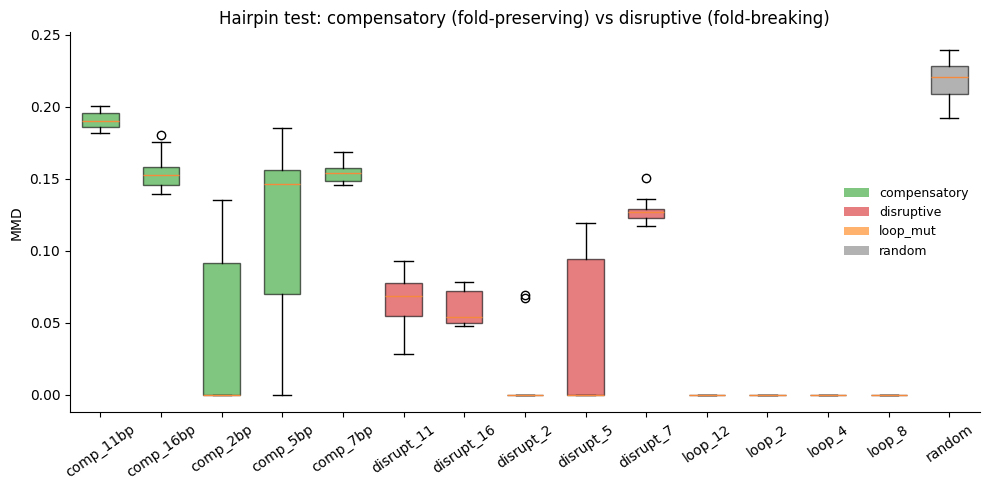

In [10]:
# Plot: compensatory vs disruptive
cat_colors = {"compensatory": "#2ca02c", "disruptive": "#d62728",
              "loop_mut": "#ff7f0e", "random": "#7f7f7f"}

fig, ax = plt.subplots(figsize=(10, 5))

conditions_hp = []
data_hp = []
colors_hp = []
for cat in ["compensatory", "disruptive", "loop_mut", "random"]:
    for cond in sorted(hp_df[hp_df.category == cat]["condition"].unique()):
        vals = hp_df[hp_df.condition == cond]["mmd"].values
        conditions_hp.append(cond)
        data_hp.append(vals)
        colors_hp.append(cat_colors[cat])

bp = ax.boxplot(data_hp, tick_labels=conditions_hp, showfliers=True,
                patch_artist=True, widths=0.6)
for patch, c in zip(bp["boxes"], colors_hp):
    patch.set_facecolor(c); patch.set_alpha(0.6)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.6, label=cat)
                   for cat, c in cat_colors.items()]
ax.legend(handles=legend_elements, frameon=False, fontsize=9)

ax.set_ylabel("MMD")
ax.set_title("Hairpin test: compensatory (fold-preserving) vs disruptive (fold-breaking)")
ax.tick_params(axis="x", rotation=35)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Within-class vs between-class MMD distributions

Sample many real ncRNAs per class, compute pairwise MMD within and between classes.

In [12]:
# Collect sequences per class
CLASSES = {"tRNA": [], "snoRNA": [], "snRNA": [], "miRNA": []}
MAX_PER_CLASS = 40

for t in bed_data:
    bt = None
    if t.id.startswith("tRNA-") and "Und-NNN" not in t.id:
        bt = "tRNA"
    else:
        bt = biotype_map.get(t.id.split(".")[0])
    if bt not in CLASSES or len(CLASSES[bt]) >= MAX_PER_CLASS:
        continue
    seq = sn._get_spliced_sequence(t, accessor)
    if not seq or "N" in seq.upper() or len(seq) < 40 or len(seq) > 300:
        continue
    CLASSES[bt].append(seq.upper().replace("T", "U"))

# Drop empty classes
CLASSES = {bt: seqs for bt, seqs in CLASSES.items() if len(seqs) >= 5}

for bt, seqs in CLASSES.items():
    lens = [len(s) for s in seqs]
    print(f"  {bt}: {len(seqs)} sequences, {min(lens)}-{max(lens)} nt")

  tRNA: 40 sequences, 61-159 nt
  snoRNA: 39 sequences, 68-182 nt
  miRNA: 40 sequences, 56-164 nt


In [13]:
# Pre-embed all sequences
class_embs = {}
for bt, seqs in CLASSES.items():
    print(f"Embedding {bt}...")
    class_embs[bt] = [emb(s) for s in seqs]
    print(f"  done: {len(class_embs[bt])} embeddings")
print("All embedded")

Embedding tRNA...
  done: 40 embeddings
Embedding snoRNA...
  done: 39 embeddings
Embedding miRNA...
  done: 40 embeddings
All embedded


In [14]:
# Compute within-class and between-class pairwise MMDs
import itertools

MAX_PAIRS = 200  # cap per comparison to keep runtime manageable
rng_cls = random.Random(SEED)

def sample_pairs(n, max_pairs, rng):
    """Sample pairs of indices."""
    all_pairs = [(i, j) for i in range(n) for j in range(i+1, n)]
    if len(all_pairs) <= max_pairs:
        return all_pairs
    return rng.sample(all_pairs, max_pairs)

# Within-class
within = {}
for bt in CLASSES:
    embs = class_embs[bt]
    pairs_idx = sample_pairs(len(embs), MAX_PAIRS, rng_cls)
    mmds = [sn._compute_mmd(embs[i], embs[j]) for i, j in pairs_idx]
    within[bt] = np.array(mmds)
    print(f"  within {bt}: {len(mmds)} pairs, median={np.median(mmds):.4f}")

# Between-class
between = {}
class_names = list(CLASSES.keys())
for i in range(len(class_names)):
    for j in range(i+1, len(class_names)):
        bt1, bt2 = class_names[i], class_names[j]
        embs1, embs2 = class_embs[bt1], class_embs[bt2]
        all_cross = [(a, b) for a in range(len(embs1)) for b in range(len(embs2))]
        if len(all_cross) > MAX_PAIRS:
            all_cross = rng_cls.sample(all_cross, MAX_PAIRS)
        mmds = [sn._compute_mmd(embs1[a], embs2[b]) for a, b in all_cross]
        label = f"{bt1} vs {bt2}"
        between[label] = np.array(mmds)
        print(f"  {label}: {len(mmds)} pairs, median={np.median(mmds):.4f}")

# Also: within-class vs genomic noise
noise_embs = [emb(s) for s in noise_seqs[:20]]
for bt in CLASSES:
    embs = class_embs[bt]
    pairs_cross = [(a, b) for a in range(len(embs)) for b in range(len(noise_embs))]
    if len(pairs_cross) > MAX_PAIRS:
        pairs_cross = rng_cls.sample(pairs_cross, MAX_PAIRS)
    mmds = [sn._compute_mmd(embs[a], noise_embs[b]) for a, b in pairs_cross]
    between[f"{bt} vs noise"] = np.array(mmds)
    print(f"  {bt} vs noise: {len(mmds)} pairs, median={np.median(mmds):.4f}")

  within tRNA: 200 pairs, median=0.0541
  within snoRNA: 200 pairs, median=0.0766
  within miRNA: 200 pairs, median=0.0804
  tRNA vs snoRNA: 200 pairs, median=0.1664
  tRNA vs miRNA: 200 pairs, median=0.1943
  snoRNA vs miRNA: 200 pairs, median=0.0930
  tRNA vs noise: 200 pairs, median=0.2093
  snoRNA vs noise: 200 pairs, median=0.1121
  miRNA vs noise: 200 pairs, median=0.1125


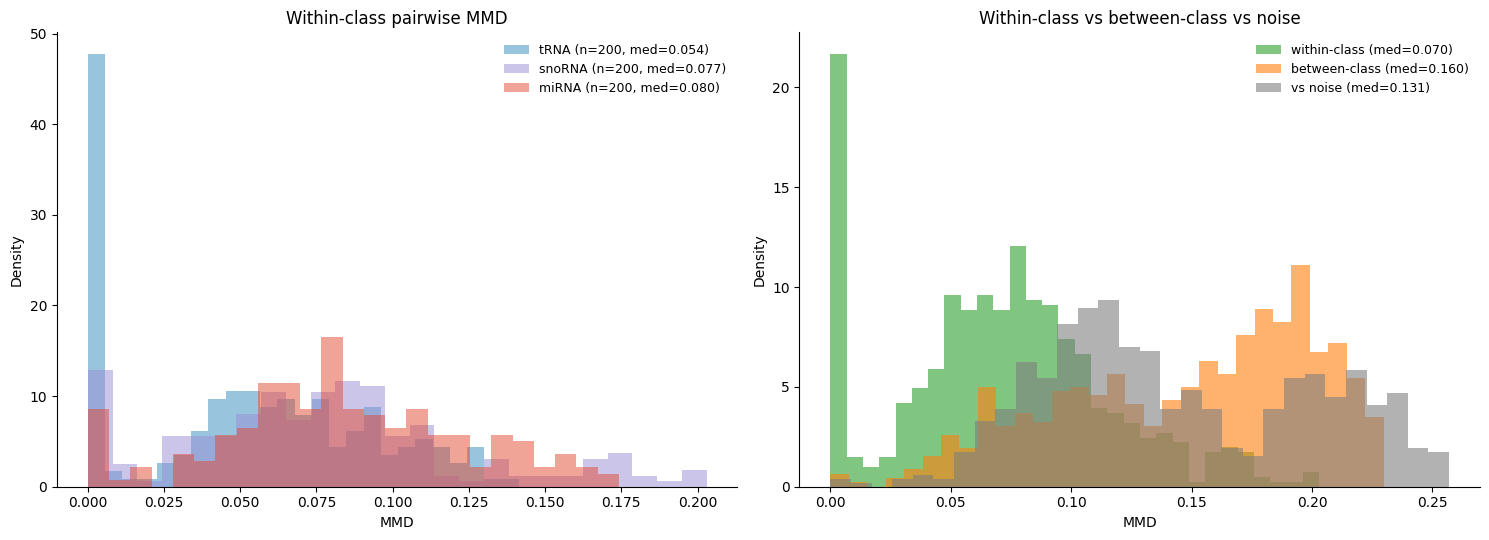


Within-class:   median=0.0702, P95=0.1480
Between-class:  median=0.1603, P5=0.0540
vs noise:       median=0.1307, P5=0.0661


In [15]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel 1: Within-class distributions
ax = axes[0]
within_colors = {"tRNA": "#348abd", "snoRNA": "#988ed5", "snRNA": "#8eba42", "miRNA": "#e24a33"}
for bt in CLASSES:
    ax.hist(within[bt], bins=25, alpha=0.5, color=within_colors[bt],
            label=f"{bt} (n={len(within[bt])}, med={np.median(within[bt]):.3f})", density=True)
ax.set_xlabel("MMD")
ax.set_ylabel("Density")
ax.set_title("Within-class pairwise MMD")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel 2: Within vs between (aggregate)
ax = axes[1]
all_within = np.concatenate(list(within.values()))
between_classes_only = np.concatenate([v for k, v in between.items() if "noise" not in k])
vs_noise = np.concatenate([v for k, v in between.items() if "noise" in k])

ax.hist(all_within, bins=30, alpha=0.6, color="#2ca02c",
        label=f"within-class (med={np.median(all_within):.3f})", density=True)
ax.hist(between_classes_only, bins=30, alpha=0.6, color="#ff7f0e",
        label=f"between-class (med={np.median(between_classes_only):.3f})", density=True)
ax.hist(vs_noise, bins=30, alpha=0.6, color="#7f7f7f",
        label=f"vs noise (med={np.median(vs_noise):.3f})", density=True)
ax.set_xlabel("MMD")
ax.set_ylabel("Density")
ax.set_title("Within-class vs between-class vs noise")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nWithin-class:   median={np.median(all_within):.4f}, P95={np.percentile(all_within, 95):.4f}")
print(f"Between-class:  median={np.median(between_classes_only):.4f}, P5={np.percentile(between_classes_only, 5):.4f}")
print(f"vs noise:       median={np.median(vs_noise):.4f}, P5={np.percentile(vs_noise, 5):.4f}")

## Does PCA help? Raw 1280-dim vs PCA-reduced

The pipeline uses PCA(16) on RNA-FM. Let's try PCA on RiNALMo embeddings
and see if within/between-class separation improves.

In [16]:
from sklearn.decomposition import PCA

# Stack all per-token embeddings (ncRNA + noise) to fit PCA
# Same approach as the pipeline's fit_pca.py
all_tokens = []
for bt in CLASSES:
    for e in class_embs[bt]:
        all_tokens.append(e)  # (L, 1280)
for s in noise_seqs[:20]:
    all_tokens.append(emb(s))

X_pool = np.vstack(all_tokens).astype(np.float32)
print(f"PCA training pool: {X_pool.shape} ({X_pool.shape[0]} tokens x {X_pool.shape[1]} dims)")

# Test different k values
K_VALUES = [8, 16, 32, 64]
pca_models = {}
for k in K_VALUES:
    pca = PCA(n_components=k).fit(X_pool)
    pca_models[k] = pca
    var = pca.explained_variance_ratio_.sum()
    print(f"  k={k}: {var:.1%} variance")

PCA training pool: (12164, 1280) (12164 tokens x 1280 dims)
  k=8: 38.2% variance
  k=16: 50.6% variance
  k=32: 61.3% variance
  k=64: 71.0% variance


In [17]:
# Recompute within/between-class MMD in each PCA space
def compute_class_mmds(embs_dict, noise_embs_list, pca=None):
    """Compute within/between class MMDs, optionally PCA-transforming first."""
    def transform(e):
        return pca.transform(e) if pca else e

    result = {}
    class_names = list(embs_dict.keys())
    rng_p = random.Random(SEED)

    # Within-class
    for bt in class_names:
        embs = [transform(e) for e in embs_dict[bt]]
        pairs_idx = sample_pairs(len(embs), 200, rng_p)
        mmds = [sn._compute_mmd(embs[i], embs[j]) for i, j in pairs_idx]
        result[f"within_{bt}"] = np.array(mmds)

    # Between-class
    for i in range(len(class_names)):
        for j in range(i+1, len(class_names)):
            bt1, bt2 = class_names[i], class_names[j]
            e1 = [transform(e) for e in embs_dict[bt1]]
            e2 = [transform(e) for e in embs_dict[bt2]]
            cross = [(a, b) for a in range(len(e1)) for b in range(len(e2))]
            if len(cross) > 200:
                cross = rng_p.sample(cross, 200)
            mmds = [sn._compute_mmd(e1[a], e2[b]) for a, b in cross]
            result[f"{bt1}_vs_{bt2}"] = np.array(mmds)

    # vs noise
    n_embs = [transform(e) for e in noise_embs_list]
    for bt in class_names:
        e = [transform(e_) for e_ in embs_dict[bt]]
        cross = [(a, b) for a in range(len(e)) for b in range(len(n_embs))]
        if len(cross) > 200:
            cross = rng_p.sample(cross, 200)
        mmds = [sn._compute_mmd(e[a], n_embs[b]) for a, b in cross]
        result[f"{bt}_vs_noise"] = np.array(mmds)

    return result

# Compute for raw + each PCA
print("Computing raw (1280-dim)...")
raw_results = compute_class_mmds(class_embs, [emb(s) for s in noise_seqs[:20]])

pca_results = {}
for k in K_VALUES:
    print(f"Computing PCA k={k}...")
    pca_results[k] = compute_class_mmds(class_embs, [emb(s) for s in noise_seqs[:20]], pca_models[k])

print("Done")

Computing raw (1280-dim)...
Computing PCA k=8...
Computing PCA k=16...
Computing PCA k=32...
Computing PCA k=64...
Done


In [18]:
# Compare: within-class median vs between-class median for each space
print(f"{'Space':>12s} | {'Within med':>10s} | {'Between med':>11s} | {'vs Noise med':>12s} | {'Ratio B/W':>9s} | {'Ratio N/W':>9s}")
print("-" * 80)

def summarize(results):
    within_vals = np.concatenate([v for k, v in results.items() if k.startswith("within_")])
    between_vals = np.concatenate([v for k, v in results.items()
                                   if "_vs_" in k and "noise" not in k])
    noise_vals = np.concatenate([v for k, v in results.items() if "noise" in k])
    w = np.median(within_vals)
    b = np.median(between_vals)
    n = np.median(noise_vals)
    return w, b, n

w, b, n = summarize(raw_results)
print(f"{'Raw 1280':>12s} | {w:>10.4f} | {b:>11.4f} | {n:>12.4f} | {b/w:>9.1f}x | {n/w:>9.1f}x")

for k in K_VALUES:
    w, b, n = summarize(pca_results[k])
    print(f"{'PCA k=' + str(k):>12s} | {w:>10.4f} | {b:>11.4f} | {n:>12.4f} | {b/w:>9.1f}x | {n/w:>9.1f}x")

       Space | Within med | Between med | vs Noise med | Ratio B/W | Ratio N/W
--------------------------------------------------------------------------------
    Raw 1280 |     0.0702 |      0.1603 |       0.1307 |       2.3x |       1.9x
     PCA k=8 |     0.0000 |      0.1956 |       0.1711 |       infx |       infx
    PCA k=16 |     0.0592 |      0.2171 |       0.2032 |       3.7x |       3.4x
    PCA k=32 |     0.0724 |      0.2116 |       0.1804 |       2.9x |       2.5x
    PCA k=64 |     0.0752 |      0.1965 |       0.1647 |       2.6x |       2.2x


/var/folders/z7/ft06s3jj3qggbhqby221m2200000kt/T/ipykernel_65800/3912930337.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"{'PCA k=' + str(k):>12s} | {w:>10.4f} | {b:>11.4f} | {n:>12.4f} | {b/w:>9.1f}x | {n/w:>9.1f}x")


In [19]:
# Per-class breakdown for raw vs best PCA
print("\nPer-class within-class MMD: Raw vs PCA")
print(f"{'Class':>10s} | {'Raw':>8s}", end="")
for k in K_VALUES:
    print(f" | {'k='+str(k):>8s}", end="")
print()
print("-" * (12 + 11 * (1 + len(K_VALUES))))

for bt in CLASSES:
    raw_w = np.median(raw_results[f"within_{bt}"])
    print(f"{bt:>10s} | {raw_w:>8.4f}", end="")
    for k in K_VALUES:
        pca_w = np.median(pca_results[k][f"within_{bt}"])
        print(f" | {pca_w:>8.4f}", end="")
    print()

print(f"\n{'vs noise':>10s} |          ", end="")
print()
for bt in CLASSES:
    raw_n = np.median(raw_results[f"{bt}_vs_noise"])
    print(f"{bt:>10s} | {raw_n:>8.4f}", end="")
    for k in K_VALUES:
        pca_n = np.median(pca_results[k][f"{bt}_vs_noise"])
        print(f" | {pca_n:>8.4f}", end="")
    print()


Per-class within-class MMD: Raw vs PCA
     Class |      Raw |      k=8 |     k=16 |     k=32 |     k=64
-------------------------------------------------------------------
      tRNA |   0.0541 |   0.0000 |   0.0000 |   0.0000 |   0.0560
    snoRNA |   0.0766 |   0.0337 |   0.0716 |   0.0794 |   0.0761
     miRNA |   0.0804 |   0.0000 |   0.1016 |   0.1022 |   0.0947

  vs noise |          
      tRNA |   0.2093 |   0.2941 |   0.3020 |   0.2773 |   0.2571
    snoRNA |   0.1121 |   0.1383 |   0.1689 |   0.1489 |   0.1370
     miRNA |   0.1125 |   0.1181 |   0.1812 |   0.1561 |   0.1392


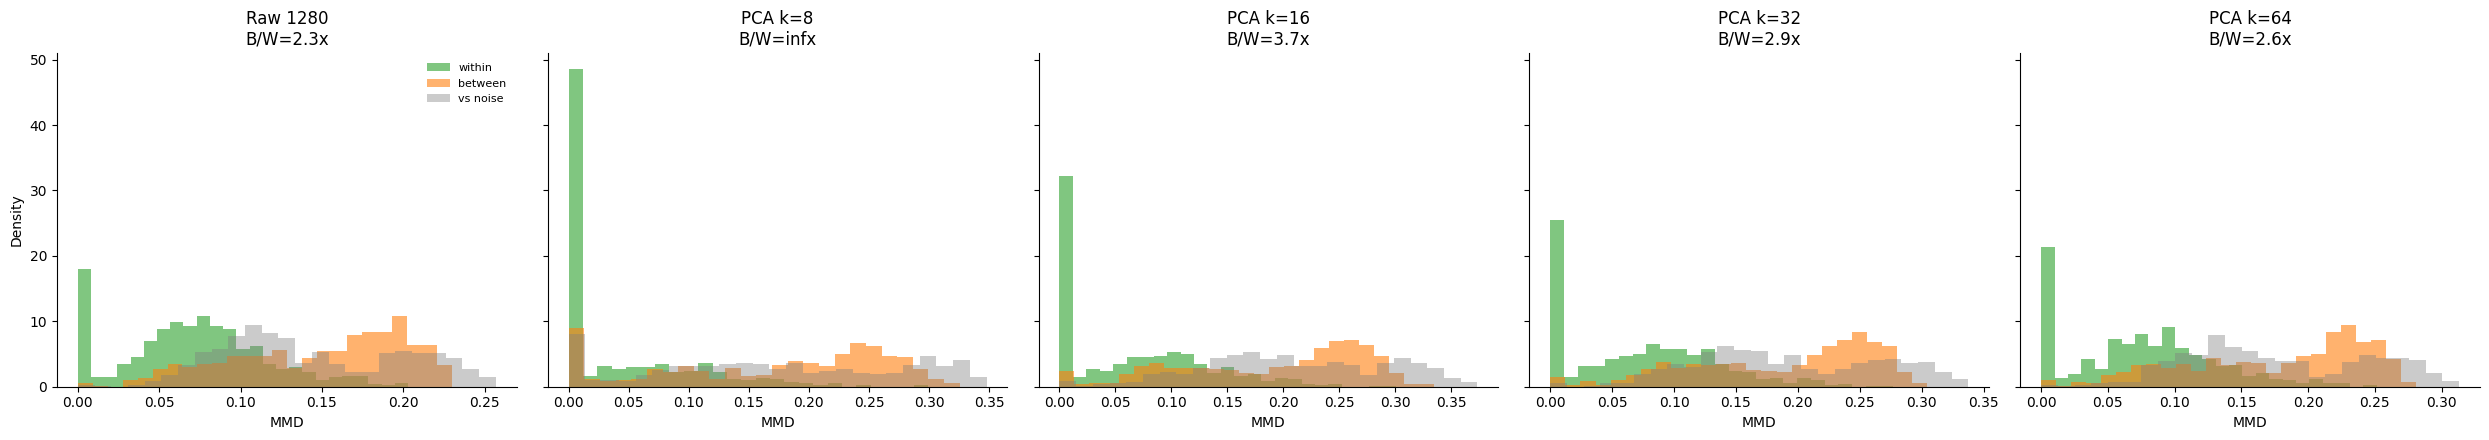

In [20]:
# Visual comparison: within vs between histograms for raw vs best PCA
fig, axes = plt.subplots(1, len(K_VALUES) + 1, figsize=(5 * (len(K_VALUES) + 1), 4.5), sharey=True)

all_setups = [("Raw 1280", raw_results)] + [(f"PCA k={k}", pca_results[k]) for k in K_VALUES]

for idx, (title, results) in enumerate(all_setups):
    ax = axes[idx]
    within_vals = np.concatenate([v for k, v in results.items() if k.startswith("within_")])
    between_vals = np.concatenate([v for k, v in results.items()
                                   if "_vs_" in k and "noise" not in k])
    noise_vals = np.concatenate([v for k, v in results.items() if "noise" in k])

    ax.hist(within_vals, bins=25, alpha=0.6, color="#2ca02c", label="within", density=True)
    ax.hist(between_vals, bins=25, alpha=0.6, color="#ff7f0e", label="between", density=True)
    ax.hist(noise_vals, bins=25, alpha=0.4, color="#7f7f7f", label="vs noise", density=True)

    w, b, n = np.median(within_vals), np.median(between_vals), np.median(noise_vals)
    ratio = b / w if w > 0 else float("inf")
    ax.set_title(f"{title}\nB/W={ratio:.1f}x")
    ax.set_xlabel("MMD")
    if idx == 0:
        ax.set_ylabel("Density")
        ax.legend(frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Recalibrate the MMD ruler with PCA k=16

In [21]:
# Redo the full calibration in PCA k=16 space
pca16 = pca_models[16]

def emb_pca(seq):
    return pca16.transform(emb(seq))

def mmd_pca(a_seq, b_seq):
    return sn._compute_mmd(emb_pca(a_seq), emb_pca(b_seq))

pca_cal_rows = []
rng2 = random.Random(SEED)

for label, seq in ref_seqs.items():
    L = len(seq)
    print(f"\n=== {label} ({L} nt) ===")

    pca_cal_rows.append({"ref": label, "condition": "identical", "mmd": 0.0})

    # Point mutations
    for frac in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
        for _ in range(N_REP):
            mut = point_mutate(seq, frac, rng2)
            pca_cal_rows.append({"ref": label, "condition": f"mut_{int(frac*100)}%",
                                 "mmd": mmd_pca(seq, mut)})
        print(f"  mut {int(frac*100)}%: done")

    # Insertions
    for ins_len in [1, 2, 5, 10, 20]:
        for _ in range(N_REP):
            pos = rng2.randint(0, L)
            modified = insert_at(seq, pos, ins_len, rng2)
            pca_cal_rows.append({"ref": label, "condition": f"ins_{ins_len}",
                                 "mmd": mmd_pca(seq, modified)})
        print(f"  ins +{ins_len}: done")

    # Deletions
    for del_len in [1, 2, 5, 10, 20]:
        if del_len >= L:
            continue
        for _ in range(N_REP):
            pos = rng2.randint(0, L - del_len)
            modified = delete_at(seq, pos, del_len)
            pca_cal_rows.append({"ref": label, "condition": f"del_{del_len}",
                                 "mmd": mmd_pca(seq, modified)})
        print(f"  del -{del_len}: done")

    # Shifts
    for shift in [1, 2, 5, 10, 20]:
        for _ in range(N_REP):
            shifted = shift_seq(seq, shift)
            pca_cal_rows.append({"ref": label, "condition": f"shift_{shift}",
                                 "mmd": mmd_pca(seq, shifted)})
        print(f"  shift +{shift}: done")

    # Shuffled / random / noise
    for _ in range(N_REP):
        pca_cal_rows.append({"ref": label, "condition": "shuffled",
                             "mmd": mmd_pca(seq, shuffled(seq, rng2))})
    for _ in range(N_REP):
        pca_cal_rows.append({"ref": label, "condition": "random",
                             "mmd": mmd_pca(seq, random_seq(L, rng2))})
    for ns in noise_seqs[:N_REP]:
        ns_adj = ns[:L] if len(ns) >= L else ns + random_seq(L - len(ns), rng2)
        pca_cal_rows.append({"ref": label, "condition": "genomic_noise",
                             "mmd": mmd_pca(seq, ns_adj)})
    print(f"  shuffled/random/noise: done")

pca_cal_df = pd.DataFrame(pca_cal_rows)
print(f"\nTotal PCA measurements: {len(pca_cal_df)}")


=== tRNA (74 nt) (74 nt) ===
  mut 1%: done
  mut 2%: done
  mut 5%: done
  mut 10%: done
  mut 15%: done
  mut 20%: done
  mut 30%: done
  mut 50%: done
  ins +1: done
  ins +2: done
  ins +5: done
  ins +10: done
  ins +20: done
  del -1: done
  del -2: done
  del -5: done
  del -10: done
  del -20: done
  shift +1: done
  shift +2: done
  shift +5: done
  shift +10: done
  shift +20: done
  shuffled/random/noise: done

=== miRNA (110 nt) (110 nt) ===
  mut 1%: done
  mut 2%: done
  mut 5%: done
  mut 10%: done
  mut 15%: done
  mut 20%: done
  mut 30%: done
  mut 50%: done
  ins +1: done
  ins +2: done
  ins +5: done
  ins +10: done
  ins +20: done
  del -1: done
  del -2: done
  del -5: done
  del -10: done
  del -20: done
  shift +1: done
  shift +2: done
  shift +5: done
  shift +10: done
  shift +20: done
  shuffled/random/noise: done

=== snoRNA (135 nt) (135 nt) ===
  mut 1%: done
  mut 2%: done
  mut 5%: done
  mut 10%: done
  mut 15%: done
  mut 20%: done
  mut 30%: done
  

In [22]:
# Side-by-side ruler: Raw vs PCA k=16
raw_summary = cal_df.groupby("condition")["mmd"].agg(["mean", "std"]).rename(columns={"mean": "raw_mean", "std": "raw_std"})
pca_summary = pca_cal_df.groupby("condition")["mmd"].agg(["mean", "std"]).rename(columns={"mean": "pca_mean", "std": "pca_std"})
combined = raw_summary.join(pca_summary)
combined = combined.loc[[c for c in cond_order if c in combined.index]]

print(f"{'Condition':>15s}  {'Raw 1280':>12s}  {'PCA k=16':>12s}  {'Change':>8s}")
print("-" * 55)
for cond in combined.index:
    r = combined.loc[cond]
    raw_v = f"{r['raw_mean']:.4f}"
    pca_v = f"{r['pca_mean']:.4f}"
    if r['raw_mean'] > 0.001:
        change = f"{r['pca_mean'] / r['raw_mean']:.1f}x"
    else:
        change = "—"
    print(f"{cond:>15s}  {raw_v:>12s}  {pca_v:>12s}  {change:>8s}")

      Condition      Raw 1280      PCA k=16    Change
-------------------------------------------------------
      identical        0.0000        0.0000         —
         mut_1%        0.0000        0.0000         —
         mut_2%        0.0000        0.0000         —
         mut_5%        0.0022        0.0113      5.1x
        mut_10%        0.0136        0.0165      1.2x
        mut_15%        0.0515        0.0447      0.9x
        mut_20%        0.0851        0.0869      1.0x
        mut_30%        0.1288        0.1686      1.3x
        mut_50%        0.1657        0.2453      1.5x
          ins_1        0.0000        0.0000         —
          ins_2        0.0000        0.0000         —
          ins_5        0.0008        0.0000         —
         ins_10        0.0166        0.0056      0.3x
         ins_20        0.0305        0.0254      0.8x
          del_1        0.0000        0.0000         —
          del_2        0.0000        0.0000         —
          del_5        0.0

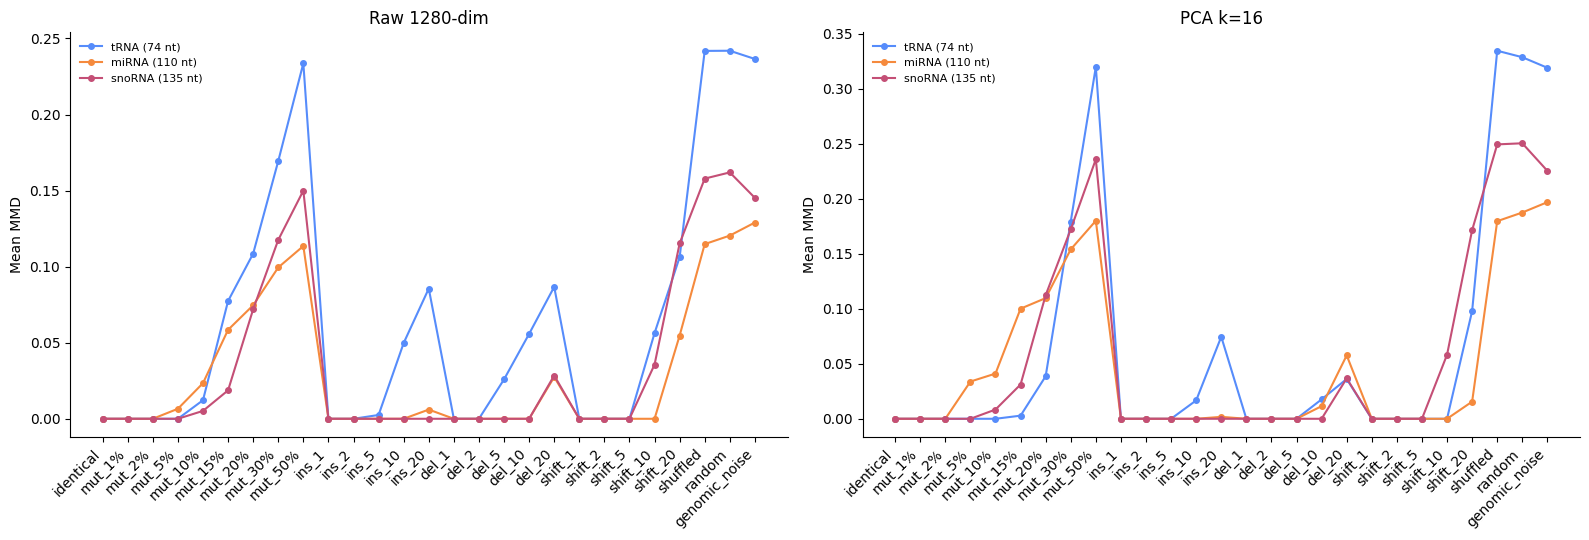

In [23]:
# Visual comparison: Raw vs PCA k=16 calibration curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for idx, (title, df_cal) in enumerate([("Raw 1280-dim", cal_df), ("PCA k=16", pca_cal_df)]):
    ax = axes[idx]
    for label in ref_seqs:
        sub = df_cal[df_cal.ref == label]
        means = [sub[sub.condition == c]["mmd"].mean() if len(sub[sub.condition == c]) > 0 else 0
                 for c in cond_order]
        ax.plot(range(len(cond_order)), means, marker="o", ms=4, label=label, lw=1.5)
    ax.set_xticks(range(len(cond_order)))
    ax.set_xticklabels(cond_order, rotation=45, ha="right")
    ax.set_ylabel("Mean MMD")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## RiNALMo PCA k=16 — final MMD ruler

In [24]:
# Final ruler for PCA k=16
print("=" * 75)
print("RINALMO PCA k=16 — MMD RULER")
print("=" * 75)

def pca_range(condition):
    vals = pca_cal_df[pca_cal_df.condition == condition]["mmd"]
    return vals.mean(), vals.std()

print(f"\n{'Condition':>20s}  {'MMD':>6s} {'±std':>6s}  Interpretation")
print("-" * 75)

for cond, interp in [
    ("identical", "perfect match"),
    ("mut_1%", "~1 nt change"),
    ("mut_2%", "~2 nt changes"),
    ("mut_5%", "~4-7 nt changes"),
    ("mut_10%", "~7-14 nt changes"),
    ("mut_15%", "~11-20 nt changes"),
    ("mut_20%", "~15-27 nt changes"),
    ("mut_30%", "heavily mutated"),
    ("mut_50%", "half the sequence changed"),
    ("ins_5", "+5 nt insertion"),
    ("ins_10", "+10 nt insertion"),
    ("ins_20", "+20 nt insertion"),
    ("del_5", "-5 nt deletion"),
    ("del_10", "-10 nt deletion"),
    ("del_20", "-20 nt deletion"),
    ("shift_5", "5 nt boundary shift"),
    ("shift_10", "10 nt boundary shift"),
    ("shift_20", "20 nt boundary shift"),
    ("shuffled", "same composition, no structure"),
    ("random", "random AUGC"),
    ("genomic_noise", "real intergenic sequence"),
]:
    if cond in pca_cal_df["condition"].values:
        m, s = pca_range(cond)
        print(f"{cond:>20s}  {m:>6.4f} {s:>6.4f}  {interp}")

# Mark zones
print("\n" + "=" * 75)
print("RECOMMENDED THRESHOLDS FOR RINALMO + PCA(16):")
within_p95 = np.percentile(np.concatenate([v for k,v in pca_results[16].items() if k.startswith('within_')]), 95)
between_p5 = np.percentile(np.concatenate([v for k,v in pca_results[16].items() if '_vs_' in k and 'noise' not in k]), 5)
noise_p5 = np.percentile(np.concatenate([v for k,v in pca_results[16].items() if 'noise' in k]), 5)
print(f"  Within-class P95:  {within_p95:.4f}")
print(f"  Between-class P5:  {between_p5:.4f}")
print(f"  vs-Noise P5:       {noise_p5:.4f}")
print(f"\n  Suggested match threshold:  ~{(within_p95 + between_p5) / 2:.2f}")
print(f"  (midpoint between within-class P95 and between-class P5)")

RINALMO PCA k=16 — MMD RULER

           Condition     MMD   ±std  Interpretation
---------------------------------------------------------------------------
           identical  0.0000 0.0000  perfect match
              mut_1%  0.0000 0.0000  ~1 nt change
              mut_2%  0.0000 0.0000  ~2 nt changes
              mut_5%  0.0113 0.0240  ~4-7 nt changes
             mut_10%  0.0165 0.0300  ~7-14 nt changes
             mut_15%  0.0447 0.0488  ~11-20 nt changes
             mut_20%  0.0869 0.0597  ~15-27 nt changes
             mut_30%  0.1686 0.0589  heavily mutated
             mut_50%  0.2453 0.0627  half the sequence changed
               ins_5  0.0000 0.0000  +5 nt insertion
              ins_10  0.0056 0.0137  +10 nt insertion
              ins_20  0.0254 0.0371  +20 nt insertion
               del_5  0.0000 0.0000  -5 nt deletion
              del_10  0.0097 0.0230  -10 nt deletion
              del_20  0.0435 0.0481  -20 nt deletion
             shift_5  0.0000 0.0000  5

## The RiNALMo MMD ruler

In [6]:
# Build the ruler: what MMD range corresponds to what biological meaning
print("=" * 70)
print("RINALMO MMD RULER")
print("=" * 70)

def mmd_range(condition):
    vals = cal_df[cal_df.condition == condition]["mmd"]
    return f"{vals.mean():.4f} (±{vals.std():.4f})"

print(f"\n{'Condition':>20s}  {'Mean MMD (±std)':>20s}  Interpretation")
print("-" * 75)
print(f"{'identical':>20s}  {'0.0000':>20s}  Perfect match")

for cond, interp in [
    ("mut_1%", "~1 nt change"),
    ("mut_2%", "~2 nt changes"),
    ("mut_5%", "~4-7 nt changes"),
    ("mut_10%", "~7-14 nt changes"),
    ("mut_15%", "~11-20 nt changes"),
    ("mut_20%", "~15-27 nt changes"),
    ("mut_30%", "heavily mutated"),
    ("mut_50%", "half the sequence changed"),
    ("ins_1", "+1 nt insertion"),
    ("ins_5", "+5 nt insertion"),
    ("ins_10", "+10 nt insertion"),
    ("ins_20", "+20 nt insertion"),
    ("del_1", "-1 nt deletion"),
    ("del_5", "-5 nt deletion"),
    ("del_10", "-10 nt deletion"),
    ("del_20", "-20 nt deletion"),
    ("shift_1", "1 nt boundary shift"),
    ("shift_5", "5 nt boundary shift"),
    ("shift_10", "10 nt boundary shift"),
    ("shift_20", "20 nt boundary shift"),
    ("shuffled", "same composition, no structure"),
    ("random", "random AUGC"),
    ("genomic_noise", "real intergenic sequence"),
]:
    if cond in cal_df["condition"].values:
        print(f"{cond:>20s}  {mmd_range(cond):>20s}  {interp}")

RINALMO MMD RULER

           Condition       Mean MMD (±std)  Interpretation
---------------------------------------------------------------------------
           identical                0.0000  Perfect match
              mut_1%      0.0000 (±0.0000)  ~1 nt change
              mut_2%      0.0000 (±0.0000)  ~2 nt changes
              mut_5%      0.0022 (±0.0120)  ~4-7 nt changes
             mut_10%      0.0136 (±0.0196)  ~7-14 nt changes
             mut_15%      0.0515 (±0.0343)  ~11-20 nt changes
             mut_20%      0.0851 (±0.0329)  ~15-27 nt changes
             mut_30%      0.1288 (±0.0400)  heavily mutated
             mut_50%      0.1657 (±0.0525)  half the sequence changed
               ins_1      0.0000 (±0.0000)  +1 nt insertion
               ins_5      0.0008 (±0.0046)  +5 nt insertion
              ins_10      0.0166 (±0.0286)  +10 nt insertion
              ins_20      0.0305 (±0.0453)  +20 nt insertion
               del_1      0.0000 (±0.0000)  -1 nt deleti